In [1]:
import ROOT
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.font_manager as fm

C system headers (glibc/Xcode/Windows SDK) must be installed.
In file included from input_line_4:36:
/uscms_data/d3/lzygala/micromamba/envs/hbb_fit/bin/../lib/gcc/x86_64-conda-linux-gnu/14.3.0/include/c++/cassert:44:10: fatal error: 'assert.h' file not found
#include <assert.h>
         ^~~~~~~~~~
input_line_37:1:10: fatal error: 'dlfcn.h' file not found
#include "dlfcn.h"
         ^~~~~~~~~


In [2]:
year = "2024"
tag = "26Jun12_msd"

res_path = f"../results/{tag}/{year}/"
model_path = f"{res_path}/datacards/sr_couplingmodelModel_{year}/"
plot_path = f"{res_path}/plots"

In [3]:
#Get the data from the root files

tree = ROOT.TChain("limit")
tree.Add(f"{model_path}higgsCombine.ZH.kb_kc.MultiDimFit.mH125.root")
# tree.Add(".MultiDimFit.mH125.root")

# Prepare lists to store the data
kappa_b = []
kappa_c = []
deltaNLL = []

# Loop over the entries in the tree and extract the data
for entry in tree:
    kappa_b.append(entry.kappa_b)
    kappa_c.append(entry.kappa_c)
    deltaNLL.append(2 * entry.deltaNLL)  # Multiply by 2 for -2Δln(L)


Best-fit kappa_b: 0.9999791979789734
Best-fit kappa_c: 1.0000718832015991
Minimum -2Δln(L): 0.0
Plot saved as ../results/26Jun12_msd/2024//plots/2d_likelihood_kappa_scan_prl.pdf
Plot saved as ../results/26Jun12_msd/2024//plots/2d_likelihood_kappa_scan_prl.png


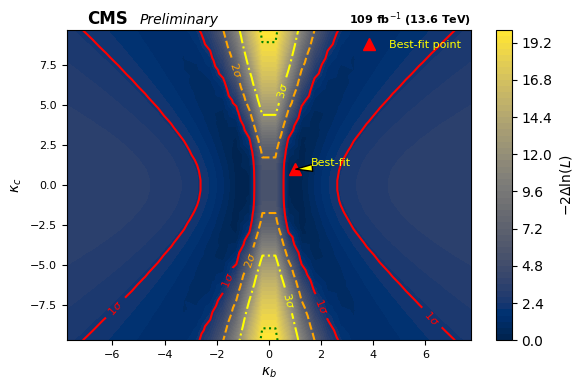

In [4]:
 # Convert lists to numpy arrays for plotting
kappa_b = np.array(kappa_b)
kappa_c = np.array(kappa_c)
deltaNLL = np.array(deltaNLL)

# Find the best-fit point
min_index = np.argmin(deltaNLL)
best_kappa_b = kappa_b[min_index]
best_kappa_c = kappa_c[min_index]
min_deltaNLL = deltaNLL[min_index]

print(f"Best-fit kappa_b: {best_kappa_b}")
print(f"Best-fit kappa_c: {best_kappa_c}")
print(f"Minimum -2Δln(L): {min_deltaNLL}")

# Define confidence level thresholds for 1σ, 2σ, etc.
confidence_levels = [2.30, 6.17, 11.83, 19.31, 27.63]

# Create the contour plot
plt.figure(figsize=(6,4))  # Compact PRL-style dimensions
contour = plt.tricontourf(kappa_b, kappa_c, deltaNLL, levels=50, cmap='cividis')

# Add a colorbar
cbar = plt.colorbar(contour)
cbar.set_label(r'$-2\Delta\ln(L)$', fontsize=10)

# Overlay confidence level contours
contour_lines = plt.tricontour(
    kappa_b, kappa_c, deltaNLL,
    levels=[min_deltaNLL + cl for cl in confidence_levels],
    colors=['red', 'orange', 'yellow', 'green', 'blue'],
    linestyles=['-', '--', '-.', ':', '-']
)

# Add confidence level labels
fmt = {min_deltaNLL + cl: f'{sigma}$\sigma$' for cl, sigma in zip(confidence_levels, range(1, 6))}
plt.clabel(contour_lines, fmt=fmt, inline=True, fontsize=8)

# Mark the best-fit point
plt.plot(best_kappa_b, best_kappa_c, 'r^', label='Best-fit point', markersize=8)
plt.annotate(
    'Best-fit', xy=(best_kappa_b, best_kappa_c), xytext=(best_kappa_b + 0.6, best_kappa_c + 0.2),
    arrowprops=dict(facecolor='yellow', shrink=0.05, width=0.5, headwidth=5),
    fontsize=8, color='yellow'  # Set the text color here
)

# PRL-style labels and text
plt.xlabel(r'$\kappa_{b}$', fontsize=10)
plt.ylabel(r'$\kappa_{c}$', fontsize=10)
plt.tick_params(axis='both', which='major', labelsize=8)
plt.grid(visible=False)

# Add CMS text
plt.text(0.05, 1.02, "CMS", fontsize=12, fontweight='bold', transform=plt.gca().transAxes)
plt.text(0.18, 1.02, "Preliminary", fontsize=10, style='italic', transform=plt.gca().transAxes)
plt.text(1.0, 1.02, r"109 fb$^{-1}$ (13.6 TeV)", fontsize=8, fontweight='bold', ha='right', transform=plt.gca().transAxes)

# Add legend
# Create the legend
legend = plt.legend(fontsize=8, loc='upper right', frameon=False)

# Change the text color in the legend
for text in legend.get_texts():
    text.set_color('yellow')  # Set your desired color

# Save and show the plot
plt.tight_layout()

output_file = f"{plot_path}/2d_likelihood_kappa_scan_prl.pdf"
plt.savefig(output_file)
print(f"Plot saved as {output_file}")

output_file = f"{plot_path}/2d_likelihood_kappa_scan_prl.png"
plt.savefig(output_file)
print(f"Plot saved as {output_file}")
plt.show()